----
# **<span style="color:SEAGREEN">PROYECTO MACHINE LEARNING ESTUDIANTES</span>**
# **<span style="color:SEAGREEN">Preporcesamiento</span>**
----

---
---
## <span style="color:gray">**Importación de librerías**</span> 📂

In [4]:
# Importación de librerías
# -----------------------------------------------------------------------
# Manipulación de datos
import numpy as np
import pandas as pd
import math

# Estadística y normalización
from scipy.stats import zscore, mstats
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

---
---
## <span style="color:gray">**Carga de datos**</span> 📥

In [5]:
# Configuración de Pandas
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None)  # Para visualizar todas las columnas de los DataFrames

In [6]:
df = pd.read_csv("../data/raw/dataset_estudiantes.csv")

df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


---
---
## <span style="color:gray">**Preprocesamiento**</span> ⚙️
---

### **Gestión de nulos**

#### Identificación de valores nulos

In [7]:
cantidad_nulos = df.isna().sum()  # Suma valores nulos por columna
cantidad_nulos = cantidad_nulos[cantidad_nulos != 0]  # Filtra solo columnas con valores nulos

cantidad_nulos  # Muestra el resultado

horas_sueno                  150
horario_estudio_preferido    100
estilo_aprendizaje            50
dtype: int64

#### Análisis de valores únicos en columnas categóricas con valores nulos

In [8]:
for col in cantidad_nulos.index.to_list():
    if col in df.select_dtypes(include='str'):
        display(df[col].value_counts())

horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
Name: count, dtype: int64

estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
Name: count, dtype: int64

#### Imputación de nulos

- Para las columnas categóricas (`horario_estudio_preferido` y `estilo_aprendizaje`), se utiliza el valor genérico "Desconocido" para reemplazar los valores nulos.

- Para la columna numérica `horas_sueno`, se utiliza la mediana como medida de tendencia central para reemplazar los valores faltantes.

Esta estrategia de imputación preserva la integridad del conjunto de datos mientras proporciona un tratamiento apropiado según el tipo de variable, evitando la eliminación de filas con información parcialmente completa.

In [9]:
# Valor desconocido
val = 'Desconocido'

# Columnas categoricas
cols_cat = ['horario_estudio_preferido', 'estilo_aprendizaje']

# Imputación de valores categóricos con un valor desconocido
df[cols_cat] = df[cols_cat].fillna(val)

# Imputación de valores numéricos con la mediana
df['horas_sueno'] = df['horas_sueno'].fillna(df['horas_sueno'].median())

#### Comprobación de nulos

In [10]:
nulos = df.isnull().sum().sum()
if nulos == 0:
    print('No hay nulos')

No hay nulos


---

### **Gestión de outliers**

#### Identificación de outliers mediante boxplot

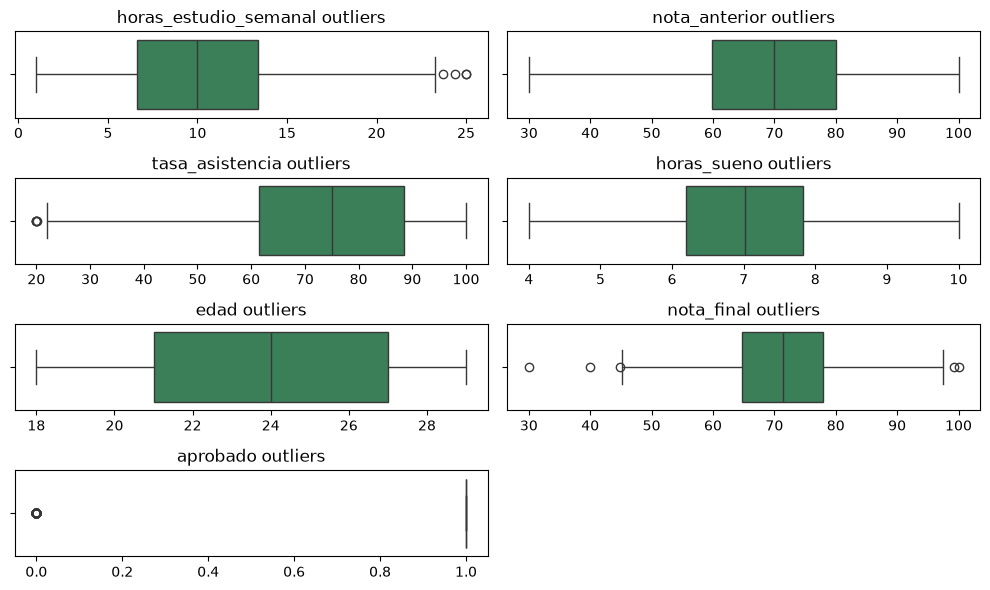

In [11]:
# Seleccionar solo columnas numéricas del DataFrame
df_num = df.select_dtypes(include=np.number)
cols_num = df_num.columns

# Calcular el número de gráficos y filas necesarias
n_plots = len(cols_num)
num_rows = math.ceil(n_plots / 2)  # Se distribuyen en 2 columnas

# Ajustar dinámicamente el tamaño de la figura
width = 5 * 2
height = 1.5 * num_rows
size = (width, height)

# Crear la estructura de subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=size)
axes = axes.flat  # Convertir matriz de ejes a lista plana

# Crear un boxplot para cada variable numérica
for i, col in enumerate(cols_num):
   sns.boxplot(
       x=col,
       data=df_num,
       color="seagreen",
       ax=axes[i]
   )

   axes[i].set_title(f'{col} outliers')
   axes[i].set_xlabel('')  # Eliminar etiqueta del eje x para mayor claridad

# Eliminar el último gráfico si sobra un espacio vacío
if n_plots % 2 != 0:
   fig.delaxes(axes[-1])

# Ajustar el layout y mostrar la figura
plt.tight_layout()
plt.show()

Variables con Outliers
 
- `horas_estudio_semanal` (Valores altos): Se observan unos 4 puntos como outliers a la derecha, por encima de las 23 horas aproximadamente. Esto indica que hay un grupo pequeño de estudiantes que dedica un tiempo excepcionalmente alto al estudio en comparación con la mayoría.
 
- `tasa_asistencia` (Valores bajos): Presenta un outlier extremo a la izquierda, alrededor del 20%. La gran mayoría de los alumnos mantiene una asistencia superior al 60%, por lo que este caso es una anomalía de muy baja participación.
 
- `nota_final` (Valores bajos y altos):Por debajo: Hay unos 3 o 4 estudiantes con notas atípicamente bajas (entre 30 y 45 puntos). Por encima: Hay 2 estudiantes con calificaciones perfectas o casi perfectas que sobresalen del límite superior (cerca de 100 puntos).
 
- `aprobado` (Valores bajos): Al ser una variable binaria (0 o 1), el gráfico se ve comprimido. El bloque principal está en 1.0 (aprobados), por lo que los estudiantes que suspendieron (valor 0.0) se marcan estadísticamente como outliers debido a que la gran mayoría aprobó.
 
Variables sin Outliers

- `nota_anterior`: La distribución está perfectamente contenida entre 30 y 100 puntos. Los bigotes cubren todo el rango sin dejar valores aislados.

- `horas_sueno`: Los hábitos de sueño están concentrados de manera uniforme entre las 4 y las 10 horas. No hay comportamientos fuera de lo común.

- `edad`: La población estudiantil se encuentra distribuida de forma compacta entre los 18 y 29 años, sin datos atípicos.

#### Detección de outliers mediante el método IQR

El método IQR (Rango Intercuartílico) sirve para encontrar datos atípicos fijándose en la posición de los estudiantes. Divide el grupo en partes y marca como "outliers" a los que se quedan muy lejos de la mayoría del centro. Lo usamos porque es un método que no se deja engañar por notas o asistencias exageradas a la hora de hacer sus cálculos.

In [12]:
# Diccionario para almacenar los outliers detectados en cada columna
outliers_dict_iqr = {}

# Iterar sobre cada columna numérica
for col in df_num.columns:
   # Calcular los cuartiles Q1 y Q3
   Q1 = df_num[col].quantile(0.25)
   Q3 = df_num[col].quantile(0.75)
   IQR = Q3 - Q1  # Calcular el rango intercuartil

   # Definir los límites para detectar outliers (método de la valla)
   lower_bound = Q1 - 1.5 * IQR
   upper_bound = Q3 + 1.5 * IQR

   # Filtrar los outliers en la columna actual
   outliers = df_num[(df_num[col] < lower_bound) | (df_num[col] > upper_bound)]
   
   # Almacenar los outliers en el diccionario
   outliers_dict_iqr[col] = outliers

In [13]:
outliers_dict_iqr['horas_estudio_semanal']

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado
384,24.389231,94.961226,79.839261,7.020701,28,71.5,1
594,25.000000,73.320156,82.741554,8.102197,22,77.7,1
695,23.737267,76.050333,58.395317,6.547218,24,72.5,1
945,25.000000,90.868031,100.000000,7.899905,23,86.7,1


In [14]:
outliers_dict_iqr['tasa_asistencia']

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado
603,10.207063,60.222635,20.000000,9.574623,19,65.7,1
630,9.072602,60.129355,20.000000,8.063128,29,64.5,1
744,6.209979,76.009529,20.050934,4.809203,23,65.0,1
974,1.000000,30.224020,20.000000,4.339117,23,50.8,0


In [15]:
outliers_dict_iqr['nota_final']

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado
323,1.000000,37.046592,24.764175,5.722487,18,40.0,0
579,1.000000,30.000000,64.240392,7.973087,29,30.0,0
606,16.609729,100.000000,100.000000,8.754101,27,99.2,1
822,2.432055,75.362436,84.842736,7.156477,27,44.9,0
927,14.827102,100.000000,72.812698,7.646091,18,100.0,1


In [16]:
outliers_dict_iqr['aprobado'].shape

(102, 7)

#### Detección de outliers mediante el método Z-score

El método Z-Score (Puntuación Estándar) sirve para encontrar datos atípicos fijándose en el promedio general. Mide qué tan lejos está cada alumno de la media del grupo. Lo usamos para tener una segunda opinión y estar completamente seguros de qué datos son verdaderas anomalías antes de tomar una decisión.

In [17]:
# Diccionario para almacenar los outliers detectados en cada columna
outliers_dict_z = {}

for col in df_num.columns:

    # Filtrar los outliers usando |Z| > 3
    outliers = df_num[np.abs(zscore(df_num[col])) > 3]

    # Almacenar los outliers en el diccionario
    outliers_dict_z[col] = outliers

outliers_df = pd.concat(outliers_dict_z.values(), keys=outliers_dict_z.keys())

In [18]:
outliers_dict_z['horas_estudio_semanal']

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado
594,25.0,73.320156,82.741554,8.102197,22,77.7,1
945,25.0,90.868031,100.000000,7.899905,23,86.7,1


In [19]:
outliers_dict_z['tasa_asistencia']

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado


In [20]:
outliers_dict_z['nota_final']

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado
323,1.0,37.046592,24.764175,5.722487,18,40.0,0
579,1.0,30.000000,64.240392,7.973087,29,30.0,0


In [21]:
outliers_dict_z['aprobado']

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado


Hallazgos por variable  

- `horas_estudio_semanal`: El IQR identificó valores atípicos altos por encima de las 24 horas, mientras que el Z-Score solo detectó los valores máximos absolutos (25 horas). Se determina que estos datos representan comportamientos reales de estudiantes con alta dedicación y no errores de captura.

- `tasa_asistencia`: El Z-Score no identificó ninguna anomalía, pero el IQR detectó un grupo con asistencias muy bajas en torno al 20%, además de un caso extremo de un alumno con apenas un 1% de asistencia. Este último registro constituye una anomalía que requiere un tratamiento diferenciado.

- `nota_final`: El IQR capturó tanto el extremo inferior (calificaciones entre 30 y 45) como el superior (notas perfectas de 99 a 100). En cambio, el Z-Score solo logró catalogar como atípicas las notas inferiores a 40, omitiendo los rendimientos perfectos.


- `aprobado`: El método IQR clasificó erróneamente 102 registros como outliers. Esto representa un error metodológico de los algoritmos automatizados, provocado por aplicar una métrica de dispersión continua a una variable categórica binaria: Como casi todos los alumnos aprobaron, el sistema cree que los pocos que suspendieron son errores, pero no lo son. El Z-Score, correctamente, no arrojó resultados para esta variable.

#### Tratamiento de los outliers y preparación por modelo

Para aprovechar al máximo la información disponible sin reducir el tamaño de la muestra, se ha decidido conservar todos los registros originales, incluidos los de los 102 alumnos que no han aprobado el curso. Sin embargo, para garantizar el éxito de cada modelo y evitar trampas matemáticas (data leakage), los datos se trataron de forma completamente independiente según el objetivo: 

- Para el Modelo de Regresión (Predecir la calificación exacta):

    - Se aplicará la técnica de Winsorization (topamiento) exclusivamente en este modelo para las variables continuas (como horas de estudio y asistencia). Los valores que se salen de los límites normales se reemplazan por un "techo" o "piso" matemático. Esto suaviza el impacto de los extremos y evita que distorsionen la línea de regresión, protegiendo la precisión en los alumnos promedio.

    - La variable `aprobado` será excluida como variable predictora para evitar que el modelo adivine la nota a partir del resultado del estado académico.

    - La variable objetivo `nota_final` no se someterá a Winsorization, ya que representa la calificación real exacta que el modelo debe aprender a calcular. Los valores extremos de esta columna (como notas de 30 o 100) fueron revisados y confirmados como rendimientos reales y válidos de los estudiantes.

- Para el Modelo de Clasificación (Predecir si aprueba o no):

    - Se utilizarán las variables continuas en su estado original (sin Winsorization). Los comportamientos extremos reales (como un alumno con 1% de asistencia) son pistas definitivas que el modelo necesita para aprender por qué alguien suspende.

    - Se eliminará por completo la variable `nota_final` de las columnas de entrada. Dejarla provocaría una fuga de datos masiva (data leakage), ya que el algoritmo simplemente memorizará que cualquier nota mayor a 60 significa aprobado, anulando su capacidad de predicción real.

    - La variable objetivo `aprobado`, al ser binaria (0 y 1), no recibe ningún tratamiento de outliers. Conservar intactos a los 102 que no aprobaron es estrictamente obligatorio para que el modelo disponga de ejemplos suficientes de ambas clases.

---

### **Para regresión**

In [22]:
# Hacemos una copia del DataFrame
df_reg = df.copy()

# Aplicamos Winsorization sobre df_reg
df_reg['horas_estudio_semanal_wins'] = mstats.winsorize(df_reg['horas_estudio_semanal'], limits=(0.01, 0.01))
df_reg['tasa_asistencia_wins'] = mstats.winsorize(df_reg['tasa_asistencia'], limits=(0.01, 0.01))

# Eliminar las columnas originales  y la columna de aprobado
columnas_a_eliminar = ['horas_estudio_semanal', 'tasa_asistencia', 'aprobado']
df_reg = df_reg.drop(columns=columnas_a_eliminar)


#### La variable objetivo es `nota_final`

In [23]:
tv = 'nota_final'

#### Codificación

In [24]:
cat_cols = df_reg.select_dtypes(include=['str', 'category']).columns
print('Variables categóricas\n\n', cat_cols)

Variables categóricas

 Index(['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido',
       'estilo_aprendizaje'],
      dtype='str')


**Ordinal Encoding**

La variable `nivel_dificultad` tiene un orden lógico natural (el nivel "Difícil" es superior al "Medio", y este al "Fácil"). Al usar una codificación ordinal personalizada, le asignamos números en escala,  esto permite a los modelos entender que a mayor número, mayor es el grado de dificultad, respetando la jerarquía original de los datos.

In [25]:
# Definimos la columna ordinal y el orden de menor a mayor
ordinal_col = ['nivel_dificultad']
orden_dificultad = [['Fácil', 'Medio', 'Difícil']]

# Codificación ordinal
ordinal_encoder = OrdinalEncoder(categories=orden_dificultad, handle_unknown='use_encoded_value', unknown_value=-1)

# Transformación directa 
df_reg[ordinal_col] = ordinal_encoder.fit_transform(df_reg[ordinal_col])

**One-hot Encoding**

A diferencia de la dificultad, el resto de columnas categóricas no tienen ningún orden o jerarquía. Este método crea columnas individuales de unos y ceros para cada opción. De esta forma, el modelo puede procesar el texto de forma justa sin asumir erróneamente que una categoría vale más que otra. 

In [26]:
# Columnas OneHot
onehot_cols = ['tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']

# Codificación OneHot
onehot_encoder = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')
onehot_encoded = onehot_encoder.fit_transform(df_reg[onehot_cols])
onehot_feature_names = onehot_encoder.get_feature_names_out()
df_onehot = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=df_reg.index)

# Concatenar con el DataFrame original y eliminar las columnas originales
df_reg = pd.concat([df_reg.drop(columns=onehot_cols), df_onehot], axis=1)

#### Guardamos el dataframe preprocesado

In [27]:
df_reg.to_csv("../data/output/df_regresion.csv")

---

### **Para clasificación**

In [28]:
# Hacemos una copia del DataFrame
df_clas = df.copy()

# Eliminar la columna nota_final
columna_a_eliminar = ['nota_final']
df_clas = df_clas.drop(columns=columna_a_eliminar)

#### La variable objetivo es `aprobado`

In [29]:
tv = 'aprobado'

#### Codificación

In [30]:
cat_cols = df_clas.select_dtypes(include=['str', 'category']).columns
print('Variables categóricas\n\n', cat_cols)

Variables categóricas

 Index(['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido',
       'estilo_aprendizaje'],
      dtype='str')


**Ordinal Encoding**

In [31]:
# Definimos la columna ordinal y el orden de menor a mayor
ordinal_col = ['nivel_dificultad']
orden_dificultad = [['Fácil', 'Medio', 'Difícil']]

# Codificación ordinal
ordinal_encoder = OrdinalEncoder(categories=orden_dificultad, handle_unknown='use_encoded_value', unknown_value=-1)

# Transformación directa 
df_clas[ordinal_col] = ordinal_encoder.fit_transform(df_clas[ordinal_col])

**One-hot Encoding**

In [32]:
# Columnas OneHot
onehot_cols = ['tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']

# Codificación OneHot
onehot_encoder = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')
onehot_encoded = onehot_encoder.fit_transform(df_clas[onehot_cols])
onehot_feature_names = onehot_encoder.get_feature_names_out()
df_onehot = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=df_clas.index)

# Concatenar con el DataFrame original y eliminar las columnas originales
df_clas = pd.concat([df_clas.drop(columns=onehot_cols), df_onehot], axis=1)

#### Guardamos el dataframe preprocesado

In [33]:
df_clas.to_csv("../data/output/df_clasificacion.csv")

---
---